In [1]:
import os
import re

import numpy as np
import torch
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
from functionsgpu_old import *
from plotting_betas import *
from video_saving import *

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
tslen = 600

functionsgpu_old.py device: cuda:1


## Loading Angle Data and Resampling

In [2]:
data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_angle"
dest_folder = "/mnt/sdb/arafat/stroke_riemann/csv_angle_resampled"
files = [file for file in os.listdir(data_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

old_data = []
new_data = []

for f in files:
    file_path = os.path.join(data_folder, f)
    g = pd.read_csv(file_path)
    
    gait_cycles = g.iloc[:,:-1].values
    n_rows = gait_cycles.shape[0]
    
    t_old = np.linspace(0, 1, gait_cycles.shape[0])
    gamma_t = np.linspace(0, 1, tslen)

    interp_func = interp1d(t_old, gait_cycles, kind='linear', axis=0, fill_value='extrapolate')
    beta_new = interp_func(gamma_t)

    gait_index = np.array([i // 100 + 1 for i in range(tslen)])
    beta_resampled = np.hstack([beta_new, gait_index.reshape(-1, 1)])
    beta_resampled = pd.DataFrame(beta_resampled, columns=g.columns)
    beta_resampled.to_csv(os.path.join(dest_folder, f), index=False)

    old_data.append(g.values)
    new_data.append(beta_resampled.values)


## Plotting

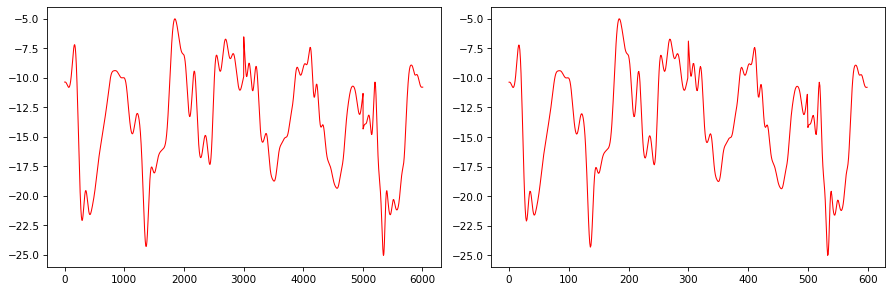

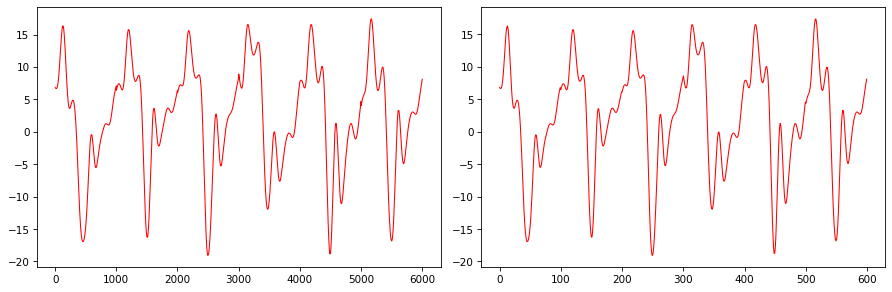

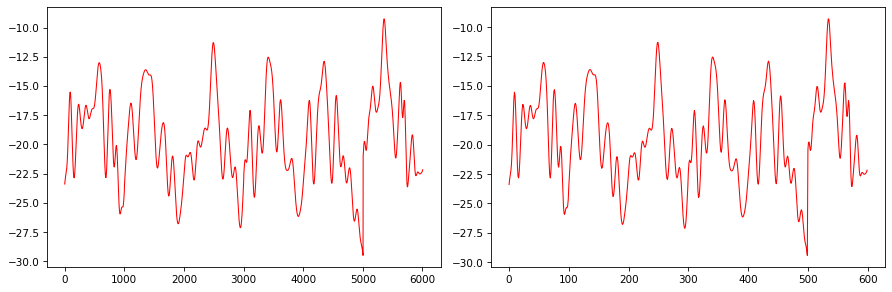

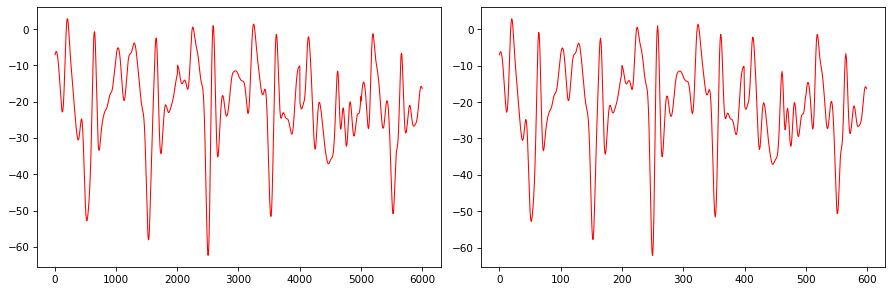

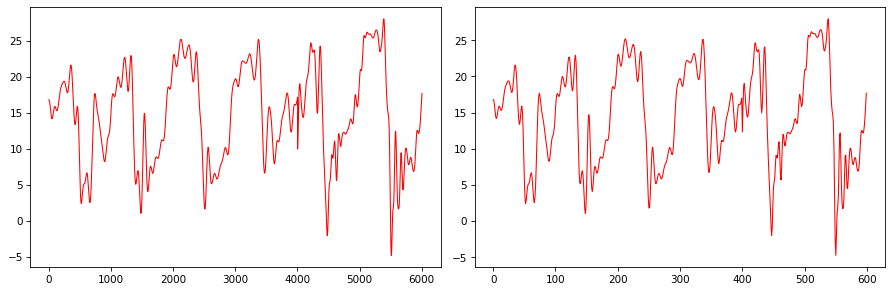

In [4]:
for o, n in zip(old_data[0:5], new_data[0:5]):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Exclude last column (gait_index) so 51 cols -> reshape (17, 3, -1)
    o = o[:, :-1].T.reshape(17, 3, -1)
    n = n[:, :-1].T.reshape(17, 3, -1)
    axes[0].plot(o[0, 2, :])
    axes[1].plot(n[0, 2, :])

    fig.tight_layout()
    plt.show()

## Resampling to 200 tslen

In [18]:
tslen = 200
data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_angle"
files = [file for file in os.listdir(data_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

old_data = []
new_data = []

for f in files:
    file_path = os.path.join(data_folder, f)
    g = pd.read_csv(file_path)
    
    gait_cycles = g.iloc[:,:-1].values
    n_rows = gait_cycles.shape[0]
    
    t_old = np.linspace(0, 1, gait_cycles.shape[0])
    gamma_t = np.linspace(0, 1, tslen)

    interp_func = interp1d(t_old, gait_cycles, kind='linear', axis=0, fill_value='extrapolate')
    beta_new = interp_func(gamma_t).T
    beta_new = beta_new.reshape(17, 3, tslen)

    old_data.append(g.values)
    new_data.append(beta_new)

angles = np.array(new_data)
angles = angles.transpose(1, 2, 3, 0)
print(angles.shape)

(17, 3, 200, 155)


## Plotting

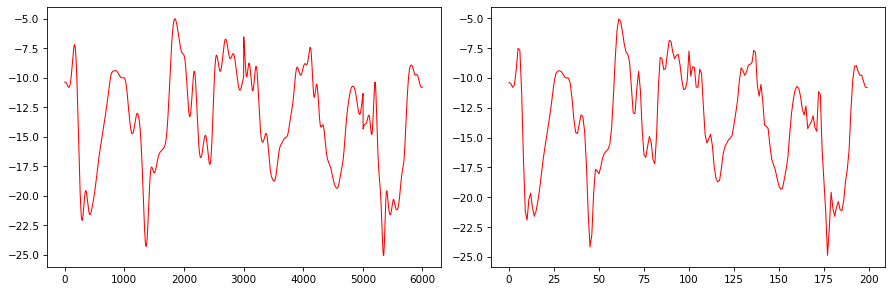

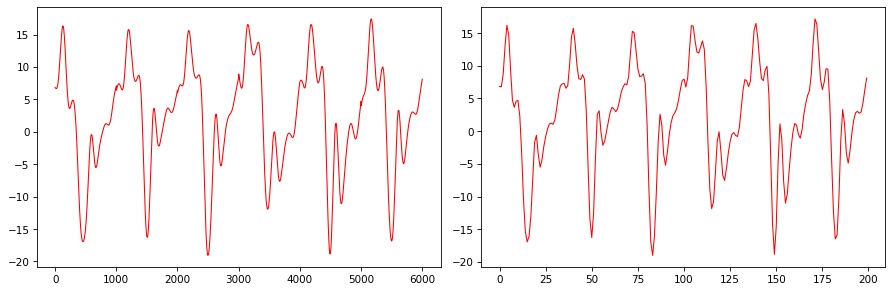

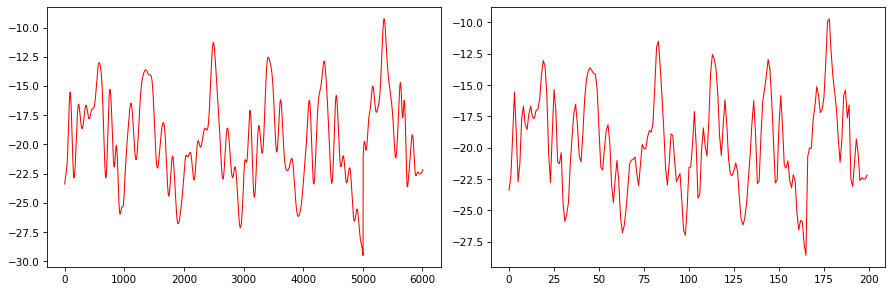

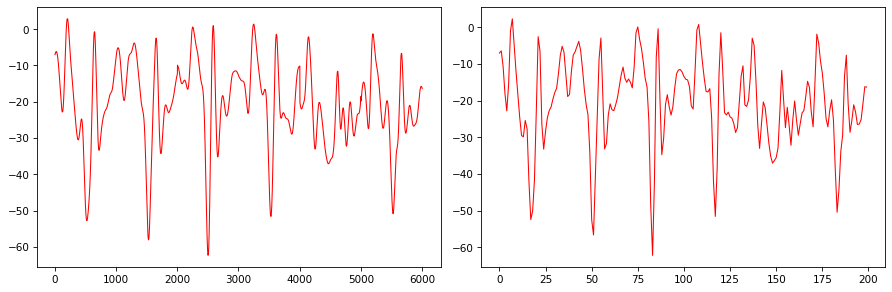

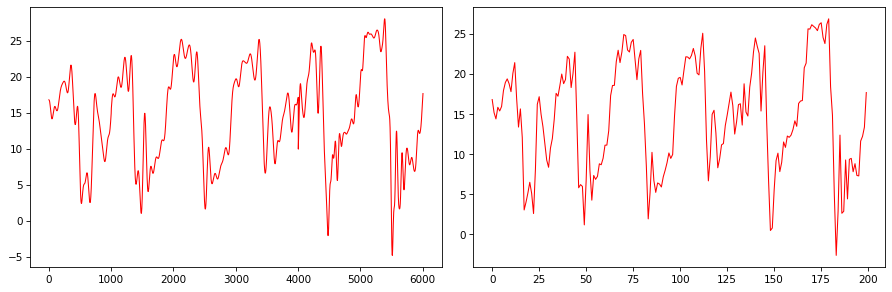

In [19]:
for i, o in enumerate(old_data[0:5]):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Exclude last column (gait_index) so 51 cols -> reshape (17, 3, -1)
    o = o[:, :-1].T.reshape(17, 3, -1)
    n = angles[:,:,:,i]
    axes[0].plot(o[0, 2, :])
    axes[1].plot(n[0, 2, :])

    fig.tight_layout()
    plt.show()

## Saving angle data (200)

In [21]:
print(angles.shape)
with open('angles.pkl', 'wb') as f:
    pickle.dump(angles, f)

(17, 3, 200, 155)


## Keeping Only Six Gaits in csv Folder

In [13]:
data_folder = "/mnt/sdb/arafat/stroke_riemann/csv"
dest_folder = "/mnt/sdb/arafat/stroke_riemann/csv_six"
files = [file for file in os.listdir(data_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

lengths = []
for f in files:
    file_path = os.path.join(data_folder, f)
    g = pd.read_csv(file_path)
    lengths.append(g.shape[0])
    
    if g.shape[0] >= 600:
        g = g.iloc[:600, :]
        g.to_csv(os.path.join(dest_folder, f), index=False)

    else:
        # g has 500 rows; take last 100 and append once
        g = pd.concat([g, g.iloc[-100:,:]], ignore_index=True)   # now 600 rows, index 0..599
        g.loc[500:599, 'Gait'] = 6   
        g.to_csv(os.path.join(dest_folder, f), index=False)

In [ ]:
dest_folder = "/mnt/sdb/arafat/stroke_riemann/csv_six"
files = [file for file in os.listdir(dest_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

lengths = []
for f in files:
    file_path = os.path.join(dest_folder, f)
    g = pd.read_csv(file_path)
    lengths.append(g.shape[0])

lengths = np.array(lengths)
np.max(lengths), np.min(lengths), np.mean(lengths), np.median(lengths)

(np.int64(600), np.int64(600), np.float64(600.0), np.float64(600.0))

## Saving Lesion Left Classfication Data

In [2]:
folder_path = "/mnt/sdb/arafat/stroke_riemann/csv_r"
files = [file for file in os.listdir(folder_path)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

participant_ids = [re.search(r'ID(\d+)_', f).group(1) for f in files]

# Create y_lesion from LesionLeft, aligned to same participant_ids order as X
demo_df = pd.read_csv('demo_data.csv')
id_to_lesion = dict(zip(demo_df['s'].astype(int), demo_df['LesionLeft']))
y_lesion = np.array([id_to_lesion[int(pid)] for pid in participant_ids])

print("LesionLeft class distribution:", np.unique(y_lesion, return_counts=True))
print("y_lesion.shape:", y_lesion.shape)

LesionLeft class distribution: (array([0, 1, 2]), array([ 30,  14, 111]))
y_lesion.shape: (155,)


In [7]:
data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_r"
dest_folder = "/mnt/sdb/arafat/stroke_riemann/csv_clf"
files = [file for file in os.listdir(data_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

for i, f in enumerate(files):
    file_path = os.path.join(data_folder, f)
    g = pd.read_csv(file_path)
    newf = f.split("_")[0] + "_" + str(y_lesion[i]) + ".csv"
    g.to_csv(os.path.join(dest_folder, newf), index=False)